In [2]:
import sys
from pathlib import Path

import numpy as np

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))

from docs.plot_setup import set_professional_style

plt = set_professional_style()

from syssimx.core.events import Event
from syssimx.system.connection import EventConnection
from syssimx.system.system import System

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
import pendulum_config as config
from fem_pendulum import FEMPendulum

---------------------

**Instantaite FEM Pendulum and Adapt Configurations**

In [3]:
model = FEMPendulum(name="FEM_Pendulum", group="Plant")

mesh_params = config.MeshParameters()
mesh_params.max_element_size = 0.1 / 6

init_params = config.InitialConditionParameters()
init_params.angular_position_deg = np.rad2deg(0.3)  # Initial angle
init_params.angular_velocity = 0
q0 = np.deg2rad(init_params.angular_position_deg)
init_params.drive_torque = 0  # Nm

mat_params = config.MaterialParameters()
mat_params.E_pendulum = 2.1e11  # Young's modulus for the pendulum
mat_params.nu_pendulum = 0.3  # Poisson's ratio for the pendulum
mat_params.rho_pendulum = 2700  # Density for the pendulum

sim_params = config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 1
sim_params.with_contact = True
sim_params.use_gravity = True

contact_params = config.ContactParameters()
contact_params.kn = 1e10

anim_params = config.AnimationParameters()
anim_params.animate = False

model.set_parameters(
    mat_params=mat_params,
    contact_params=contact_params,
    init_params=init_params,
    sim_params=sim_params,
    anim_params=anim_params,
    mesh_params=mesh_params,
)

model.initialize(0.0)


# Add event indicator for wall contact
def wall_contact_event_indicator(model: FEMPendulum) -> float:
    return model._get_contact_gap_distance()


event = Event(name="wall_hit", source=model.name, direction=-1)

model.add_event_indicator(
    name=event.name, func=wall_contact_event_indicator, direction=event.direction
)
model.subscribe_event(event)

system = System(name="FEM_Pendulum_System")
system.add_component(model)

event_connection = EventConnection(
    src_comp=model.name,
    src_port=model.output_specs["wall_hit"].name,
    dst_comp=model.name,
    dst_port=model.input_specs["omega_invert"].name,
)
system.add_event_connection(event_connection)
system.initialize(0.0)

In [4]:
# 6) Run simulation with event detection
t_start = 0.0
t_end = 1.0
dt = 0.01  # Macro step size

system.run(t0=t_start, tf=t_end, dt=dt)

  Internal hint from FEM_Pendulum: wall_hit in [0.43630000, 0.43640000]

Events detected in interval [0.43000000, 0.44000000]
Crossings: [('FEM_Pendulum', 'wall_hit')]
Internal hints: [('FEM_Pendulum', ['wall_hit'])]
  Using internal hint to narrow interval: [0.43000000, 0.44000000] -> [0.43630000, 0.43640000]
Located at t=(0.43638682, 0)
Already handled events: set()

Handling events at (0.43638682, 0): [('FEM_Pendulum', 'wall_hit')]

Events grouped by component for handling: {'FEM_Pendulum': ['wall_hit']}

Dispatching event 'wall_hit' from 'FEM_Pendulum' to targets: ['FEM_Pendulum']
[FEM_Pendulum] Event 'wall_hit' at t=0.4364s.



In [8]:
# 7) Extract and plot results
history = system.get_history()
pendulum_history = history["FEM_Pendulum"]
event_history = history["Events"]

t_vals, data = pendulum_history
q_vals = data["q"]
omega_vals = data["omega"]
alpha_vals = data["alpha"]

# Get event times
event_times = event_history.get(("FEM_Pendulum", "wall_hit"), [])
t_event = event_times[0] if event_times else None

print(f"\nDetected {len(event_times)} events")
if t_event:
    print(f"First event at t = {t_event.t:.8f} s")


Detected 1 events
First event at t = 0.43638682 s


In [9]:
event_history

{('FEM_Pendulum', 'wall_hit'): [DenseTime(t=0.4363868164062501, micro=0)]}

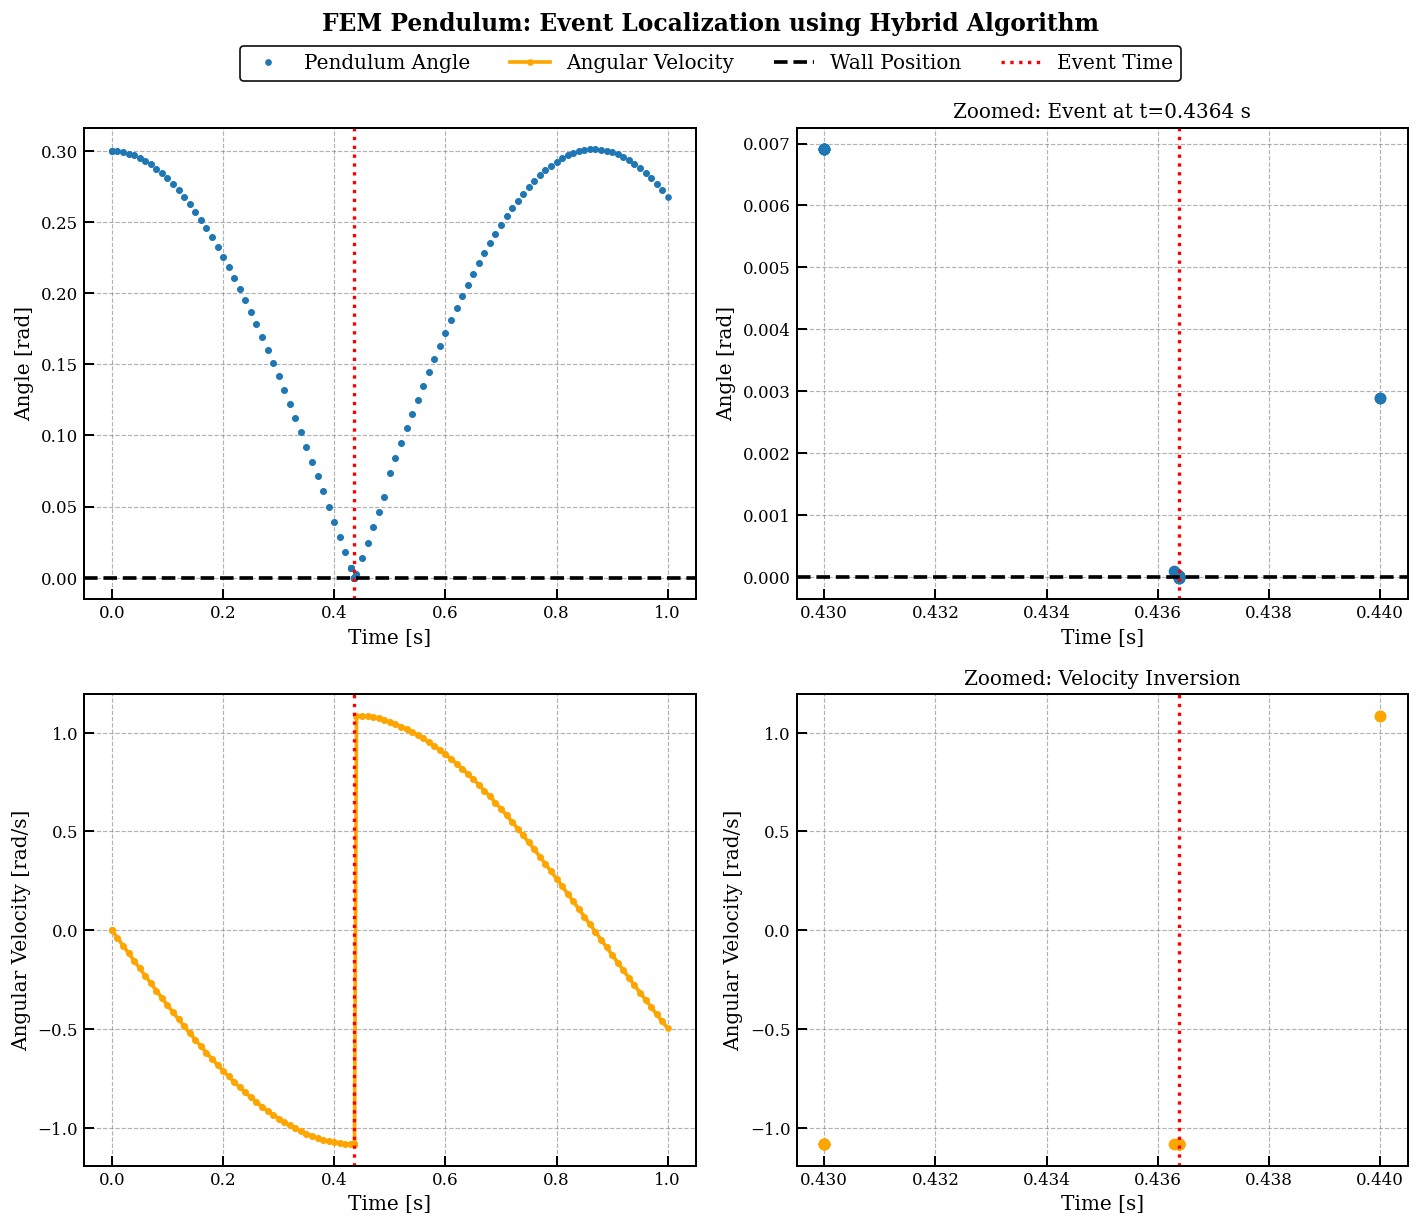

In [10]:
# 8) Visualization
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(
    "FEM Pendulum: Event Localization using Hybrid Algorithm",
    fontweight="bold",
    fontsize=14,
    y=1.02,
)

# Top left: Full angle trajectory
(line1,) = axs[0, 0].plot(
    t_vals, q_vals, label="Pendulum Angle", marker="o", markersize=3, linestyle="None"
)
line2 = axs[0, 0].axhline(0, color="k", linestyle="--", label="Wall Position")
if t_event:
    line3 = axs[0, 0].axvline(
        t_event.t, color="red", linestyle=":", linewidth=2, label="Event Time"
    )
axs[0, 0].set_xlabel("Time [s]")
axs[0, 0].set_ylabel("Angle [rad]")
axs[0, 0].grid()

# Top right: Zoomed angle near event
if t_event:
    zoom_window = 0.01
    mask = (t_vals >= t_event.t - zoom_window) & (t_vals <= t_event.t + zoom_window)
    axs[0, 1].plot(t_vals[mask], q_vals[mask], "o", markersize=6)
    axs[0, 1].axhline(0, color="k", linestyle="--")
    axs[0, 1].axvline(t_event.t, color="red", linestyle=":", linewidth=2)
    axs[0, 1].set_xlabel("Time [s]")
    axs[0, 1].set_ylabel("Angle [rad]")
    axs[0, 1].set_title(f"Zoomed: Event at t={t_event.t:.4f} s")
    axs[0, 1].grid()

# Bottom left: Full angular velocity
(line4,) = axs[1, 0].plot(
    t_vals, omega_vals, color="orange", label="Angular Velocity", marker="o", markersize=3
)

if t_event:
    axs[1, 0].axvline(t_event.t, color="red", linestyle=":", linewidth=2)
axs[1, 0].set_xlabel("Time [s]")
axs[1, 0].set_ylabel("Angular Velocity [rad/s]")
axs[1, 0].grid()

# Bottom right: Zoomed velocity near event
if t_event:
    axs[1, 1].plot(t_vals[mask], omega_vals[mask], "o", color="orange", markersize=6)
    axs[1, 1].axvline(t_event.t, color="red", linestyle=":", linewidth=2)
    axs[1, 1].set_xlabel("Time [s]")
    axs[1, 1].set_ylabel("Angular Velocity [rad/s]")
    axs[1, 1].set_title("Zoomed: Velocity Inversion")
    axs[1, 1].grid()

signals = [line1, line4, line2, line3]  # , line5]
labels = [s.get_label() for s in signals if s is not None]
fig.legend(signals, labels, loc="upper center", bbox_to_anchor=(0.5, 1), ncol=5)

plt.tight_layout()
plt.savefig("../figures/Hybrid/test_2_location_FEM.svg")
plt.show()